# 00b — Pedestrian Priority Score (Barcelona)

Appends OSM-derived pedestrian-vs-car space features to the Barcelona augmented CSV.
**Existing columns are never recomputed or overwritten.**

**Input:** `csv/features_barcelona_with_location_id_augmented.csv`  
**Output:** `csv/features_barcelona_with_location_id_augmented_pps.csv`

### New columns

| Column | Description |
|---|---|
| `sidewalk_score` | 1.0 = both sides, 0.5 = one side / unknown, 0.0 = none |
| `cycleway_score` | 1.0 if any cycle infrastructure present, else 0.0 |
| `speed_score` | 1.0 ≤ 20 mph → 0.0 > 40 mph (pedestrian comfort proxy) |
| `lane_penalty` | Normalised lane count (0–1, higher = more car lanes) |
| `highway_type_score` | 1.0 = pedestrian/living_street → 0.0 = motorway/trunk |
| `pedestrian_priority_score` | Composite PPS = weighted sum of above (0–1, higher = more pedestrian-friendly) |

### Method
For each segment in the CSV, the notebook:
1. Fetches the OSM drivable + walkable street graph for the Barcelona neighborhood (cached).
2. Finds the nearest OSM edge to the segment midpoint via a fast spatial index.
3. Extracts raw OSM tags (`sidewalk`, `cycleway`, `maxspeed`, `lanes`, `highway`).
4. Scores and combines them into `pedestrian_priority_score`.

In [17]:
import sys
from pathlib import Path

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

ox.settings.log_console = False
ox.settings.use_cache = True

In [18]:
# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT = Path('..').resolve()
CSV_DIR   = REPO_ROOT / 'csv'
INPUT_CSV = CSV_DIR / 'features_barcelona_with_location_id_augmented.csv'
OUTPUT_CSV = CSV_DIR / 'features_barcelona_with_location_id_augmented_pps.csv'
CRS_PROJECTED = 'EPSG:25831'

# ── Barcelona neighborhoods (stored in CSV 'borough' column) ──────────────────
NEIGHBORHOODS = {
    'Eixample': 'Eixample, Barcelona, Spain',
    'Poble Sec': 'Poble Sec, Barcelona, Spain',
    'Raval': 'Raval, Barcelona, Spain',
}

ALLOWED_NEIGHBORHOODS = list(NEIGHBORHOODS.keys())  # CSV borough names

# ── Score weights ─────────────────────────────────────────────────────────────
# Must sum to 1.0.  Adjust to reflect your research priorities.
WEIGHTS = {
    'sidewalk_score':     0.30,
    'cycleway_score':     0.15,
    'speed_score':        0.20,
    'lane_penalty_inv':   0.20,   # (1 - lane_penalty) so more lanes → lower PPS
    'highway_type_score': 0.15,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'

# Max lanes used for normalisation (lanes > MAX_LANES are clipped)
MAX_LANES = 6

# OSM network type to fetch — 'all' captures pedestrian, cycle, and car edges
NETWORK_TYPE = 'all'

# ── Speed lookup (mph → score) ────────────────────────────────────────────────
SPEED_SCORE_MAP = {
    20:  1.00,
    30:  0.75,
    40:  0.40,
    50:  0.20,
    60:  0.10,
    70:  0.00,
}

# ── Highway-type score (higher = more pedestrian-friendly) ────────────────────
HIGHWAY_SCORE_MAP = {
    'pedestrian':    1.00,
    'living_street': 1.00,
    'footway':       1.00,
    'path':          0.90,
    'cycleway':      0.85,
    'residential':   0.75,
    'service':       0.65,
    'unclassified':  0.60,
    'tertiary':      0.45,
    'tertiary_link': 0.45,
    'secondary':     0.30,
    'secondary_link':0.30,
    'primary':       0.15,
    'primary_link':  0.15,
    'trunk':         0.05,
    'trunk_link':    0.05,
    'motorway':      0.00,
    'motorway_link': 0.00,
}

In [19]:
# ── Loaders ───────────────────────────────────────────────────────────────────
def load_augmented_features(csv_path):
    """Load the augmented feature CSV and attach projected geometry.
    Only rows whose `borough` (Barcelona neighborhood) is in ALLOWED_NEIGHBORHOODS are kept."""
    df = pd.read_csv(csv_path)
    if 'geometry' not in df.columns:
        raise ValueError(f'Missing geometry column in {csv_path}')
    if 'borough' in df.columns:
        df = df[df['borough'].isin(ALLOWED_NEIGHBORHOODS)].reset_index(drop=True)
    geometry = gpd.GeoSeries.from_wkt(df['geometry'], crs=CRS_PROJECTED)
    df = df.drop(columns='geometry')
    return gpd.GeoDataFrame(df, geometry=geometry, crs=CRS_PROJECTED)


def fetch_osm_edges(neighborhood_query):
    """Return a projected GeoDataFrame of OSM edges with pedestrian-relevant tags."""
    print(f'  Fetching OSM street graph (network_type={NETWORK_TYPE!r}, cached)...')
    G = ox.graph_from_place(neighborhood_query, network_type=NETWORK_TYPE)
    edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
    edges = edges.to_crs(CRS_PROJECTED)

    # Keep only the columns we need (others may be list-typed and cause issues)
    keep = ['geometry', 'highway', 'lanes', 'maxspeed', 'sidewalk', 'cycleway', 'width', 'oneway']
    existing = [c for c in keep if c in edges.columns]
    edges = edges[existing].copy()

    # Flatten list-typed OSM tag columns to their first element
    for col in ['highway', 'sidewalk', 'cycleway', 'maxspeed', 'lanes']:
        if col in edges.columns:
            edges[col] = edges[col].apply(
                lambda v: v[0] if isinstance(v, list) else v
            )

    print(f'  {len(edges):,} OSM edges loaded.')
    return edges.reset_index(drop=True)

In [20]:
# ── Nearest-edge matching ─────────────────────────────────────────────────────
def build_edge_index(edges_gdf):
    """Build a cKDTree of edge midpoints for fast nearest-neighbour lookup."""
    midpoints = edges_gdf.geometry.apply(
        lambda g: g.interpolate(0.5, normalized=True)
        if g.geom_type in ('LineString', 'MultiLineString')
        else g.centroid
    )
    coords = np.array([(p.x, p.y) for p in midpoints])
    return cKDTree(coords)


def match_segments_to_edges(segments_gdf, edges_gdf, tree):
    """For each segment return the index of the nearest OSM edge."""
    seg_midpoints = segments_gdf.geometry.apply(
        lambda g: g.interpolate(0.5, normalized=True)
        if g.geom_type in ('LineString', 'MultiLineString')
        else g.centroid
    )
    seg_coords = np.array([(p.x, p.y) for p in seg_midpoints])
    _, indices = tree.query(seg_coords)
    return indices

In [21]:
# ── Scoring functions ─────────────────────────────────────────────────────────
def score_sidewalk(val):
    """Score sidewalk OSM tag.
    'both' → 1.0 | 'left'/'right'/'yes' → 0.5 | 'no'/'none' → 0.0 | NaN → 0.5
    """
    if pd.isna(val):
        return 0.5   # unknown → neutral
    v = str(val).strip().lower()
    if v == 'both':
        return 1.0
    if v in ('left', 'right', 'yes', 'separate'):
        return 0.5
    if v in ('no', 'none'):
        return 0.0
    return 0.5   # unrecognised tag → neutral


def score_cycleway(val):
    """1.0 if any cycle infrastructure tag is present, 0.0 if explicitly absent, 0.2 if unknown."""
    if pd.isna(val):
        return 0.2   # absence of tag ≠ confirmed absence of cycle lane
    v = str(val).strip().lower()
    if v in ('no', 'none', 'share_busway'):
        return 0.0
    # Any explicit cycleway value (lane, track, shared_lane, opposite, …)
    return 1.0


def score_speed(val):
    """Parse maxspeed string and return pedestrian comfort score."""
    if pd.isna(val):
        return 0.5   # unknown → mid score
    v = str(val).strip().lower()
    # Handle special OSM values
    if v in ('walk', 'living_street'):
        return 1.0
    if v in ('national', 'signals', 'variable'):
        return 0.25
    # Strip 'mph' or 'km/h' suffix and convert
    try:
        if 'mph' in v:
            speed_mph = float(v.replace('mph', '').strip())
        elif 'km' in v:
            speed_mph = float(v.replace('km/h', '').replace('kmh', '').strip()) * 0.621371
        else:
            # OSM default in Spain is km/h; bare numbers in Barcelona are km/h
            speed_mph = float(v) * 0.621371
    except ValueError:
        return 0.5

    # Interpolate between breakpoints
    breakpoints = sorted(SPEED_SCORE_MAP.items())   # [(20,1.0),(30,0.75),...]
    if speed_mph <= breakpoints[0][0]:
        return breakpoints[0][1]
    if speed_mph >= breakpoints[-1][0]:
        return breakpoints[-1][1]
    for (lo_speed, lo_score), (hi_speed, hi_score) in zip(breakpoints, breakpoints[1:]):
        if lo_speed <= speed_mph <= hi_speed:
            t = (speed_mph - lo_speed) / (hi_speed - lo_speed)
            return round(lo_score + t * (hi_score - lo_score), 4)
    return 0.5


def score_lanes(val):
    """Normalise lane count to [0, 1] penalty (higher = more car space)."""
    if isinstance(val, (list, tuple, np.ndarray, pd.Series)):
        val = val[0] if len(val) else np.nan
    if pd.isna(val):
        return 0.5   # unknown → mid penalty
    try:
        text = str(val).strip()
        if ';' in text:
            text = text.split(';', 1)[0].strip()
        if text.startswith('[') and text.endswith(']'):
            text = text.strip('[]').split(',')[0].strip().strip("'\"")
        n = float(text)
    except (ValueError, TypeError):
        return 0.5
    return round(float(np.clip(n, 1, MAX_LANES) - 1) / (MAX_LANES - 1), 4)


def score_highway(val):
    """Look up highway type in HIGHWAY_SCORE_MAP; default 0.5 for unknowns."""
    if pd.isna(val):
        return 0.5
    v = str(val).strip().lower()
    return HIGHWAY_SCORE_MAP.get(v, 0.5)


def compute_pps(sidewalk, cycleway, speed, lane_penalty, highway):
    """Combine sub-scores into Pedestrian Priority Score."""
    return round(
        WEIGHTS['sidewalk_score']     * sidewalk
        + WEIGHTS['cycleway_score']   * cycleway
        + WEIGHTS['speed_score']      * speed
        + WEIGHTS['lane_penalty_inv'] * (1.0 - lane_penalty)
        + WEIGHTS['highway_type_score'] * highway,
        4,
    )

In [22]:
# ── Per-neighborhood enrichment ───────────────────────────────────────────────
def enrich_neighborhood(segments_gdf, neighborhood_query):
    """Match segments to OSM edges and compute pedestrian sub-scores + PPS."""
    edges = fetch_osm_edges(neighborhood_query)
    tree  = build_edge_index(edges)
    idx   = match_segments_to_edges(segments_gdf, edges, tree)
    matched = edges.iloc[idx].reset_index(drop=True)

    result = segments_gdf.copy()
    result['sidewalk_score']     = matched['sidewalk'].apply(score_sidewalk).values   if 'sidewalk'  in matched.columns else 0.5
    result['cycleway_score']     = matched['cycleway'].apply(score_cycleway).values   if 'cycleway'  in matched.columns else 0.2
    result['speed_score']        = matched['maxspeed'].apply(score_speed).values      if 'maxspeed'  in matched.columns else 0.5
    result['lane_penalty']       = matched['lanes'].apply(score_lanes).values         if 'lanes'     in matched.columns else 0.5
    result['highway_type_score'] = matched['highway'].apply(score_highway).values     if 'highway'   in matched.columns else 0.5

    result['pedestrian_priority_score'] = [
        compute_pps(sw, cy, sp, lp, hw)
        for sw, cy, sp, lp, hw in zip(
            result['sidewalk_score'],
            result['cycleway_score'],
            result['speed_score'],
            result['lane_penalty'],
            result['highway_type_score'],
        )
    ]
    return result

In [23]:
# ── Main enrichment loop ──────────────────────────────────────────────────────
NEW_COLS = [
    'sidewalk_score', 'cycleway_score', 'speed_score',
    'lane_penalty', 'highway_type_score', 'pedestrian_priority_score',
]

base_features = load_augmented_features(INPUT_CSV)
base_features['_row_order'] = np.arange(len(base_features))

# Skip columns that already exist (idempotency guard)
cols_to_add = [c for c in NEW_COLS if c not in base_features.columns]
if not cols_to_add:
    print('All PPS columns already present — nothing to do.')
else:
    print(f'Columns to add: {cols_to_add}')
    for col in cols_to_add:
        base_features[col] = np.nan

    for neighborhood_name, neighborhood_features in base_features.groupby('borough', sort=False):
        if neighborhood_name not in ALLOWED_NEIGHBORHOODS:
            print(f'\n[WARNING] Skipping unrecognised neighborhood: {neighborhood_name!r}')
            continue

        print(f'\n══ {neighborhood_name.upper()} ══')
        # Look up the OSM query string for this neighborhood
        osm_query = NEIGHBORHOODS.get(neighborhood_name, neighborhood_name)
        enriched = enrich_neighborhood(neighborhood_features, osm_query)

        for col in cols_to_add:
            base_features.loc[enriched.index, col] = enriched[col].values

    base_features = base_features.sort_values('_row_order').drop(columns='_row_order')

    # Serialise geometry back to WKT before saving
    if 'geometry' in base_features.columns:
        base_features['geometry'] = base_features.geometry.to_wkt()

    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    base_features.to_csv(OUTPUT_CSV, index=False)
    print(f'\nSaved → {OUTPUT_CSV.name}  ({len(base_features):,} rows)')

Columns to add: ['sidewalk_score', 'cycleway_score', 'speed_score', 'lane_penalty', 'highway_type_score', 'pedestrian_priority_score']

══ EIXAMPLE ══
  Fetching OSM street graph (network_type='all', cached)...
  28,724 OSM edges loaded.

══ RAVAL ══
  Fetching OSM street graph (network_type='all', cached)...
  3,480 OSM edges loaded.

Saved → features_barcelona_with_location_id_augmented_pps.csv  (11,056 rows)


In [24]:
# ── Inspect input CSV structure ────────────────────────────────────────────────
print('Inspecting input CSV structure...')
df_inspect = pd.read_csv(INPUT_CSV)
print(f'\nColumns in {INPUT_CSV.name}:')
print(df_inspect.columns.tolist())
print(f'\nShape: {df_inspect.shape}')
print(f'\nFirst few rows:')
print(df_inspect.head())

Inspecting input CSV structure...

Columns in features_barcelona_with_location_id_augmented.csv:
['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier', 'man_made', 'railway', 'z_order', 'other_tags', 'geometry', 'lanes', 'maxspeed', 'oneway', 'sidewalk', 'cycleway', 'width', 'service', 'access', 'surface', 'smoothness', 'lit', 'bridge', 'tunnel', 'layer', 'ref', 'junction', 'oneway:cycleway', 'cycleway:both', 'cycleway:left', 'cycleway:right', 'foot', 'motor_vehicle', 'bicycle', 'footway', 'borough', 'longitude', 'latitude', 'location_id', 'lighting', 'connectivity', 'enclosure', 'visibility_blocked_ratio', 'visibility', 'public_transport_proximity_m', 'dominant_land_use_score']

Shape: (30959, 46)

First few rows:
       osm_id                             name      highway  waterway  \
0  1000038393                    Túnel Glòries      primary       NaN   
1  1000249404                    Túnel Glòries      primary       NaN   
2  1000315688        Carrer de los Castillejo

In [25]:
# ── Validation summary ────────────────────────────────────────────────────────
print('\n── PPS column summary ──')
if OUTPUT_CSV.exists():
    df = pd.read_csv(OUTPUT_CSV)
    print(f'Loaded {len(df):,} rows from {OUTPUT_CSV.name}')
    available = [c for c in NEW_COLS if c in df.columns]
    print('\nDescriptive statistics:')
    stats_df = df[available].describe().T
    cols_to_show = [c for c in ['count', 'mean', 'min', 'max'] if c in stats_df.columns]
    print(stats_df[cols_to_show].to_string())
    nan_pct = df[available].isna().mean().mul(100).round(1)
    print('\nMissing values (%): ')
    print(nan_pct.to_string())
    print('\nPPS distribution by neighborhood:')
    if 'borough' in df.columns and 'pedestrian_priority_score' in df.columns:
        print(df.groupby('borough')['pedestrian_priority_score']
              .agg(['mean', 'min', 'max'])
              .round(3)
              .to_string())
else:
    print(f'{OUTPUT_CSV} not found')


── PPS column summary ──
Loaded 11,056 rows from features_barcelona_with_location_id_augmented_pps.csv

Descriptive statistics:
                             count      mean    min   max
sidewalk_score             11056.0  0.500000  0.500  0.50
cycleway_score             11056.0  0.200000  0.200  0.20
speed_score                11056.0  0.578156  0.500  1.00
lane_penalty               11056.0  0.449376  0.000  1.00
highway_type_score         11056.0  0.873232  0.050  1.00
pedestrian_priority_score  11056.0  0.536739  0.345  0.73

Missing values (%): 
sidewalk_score               0.0
cycleway_score               0.0
speed_score                  0.0
lane_penalty                 0.0
highway_type_score           0.0
pedestrian_priority_score    0.0

PPS distribution by neighborhood:
           mean    min   max
borough                     
Eixample  0.537  0.345  0.73
Raval     0.537  0.368  0.73


Loaded 11,056 PPS rows from features_barcelona_with_location_id_augmented_pps.csv


,count,mean,min,max
pedestrian_priority_score,11056.0,0.536739,0.345,0.73


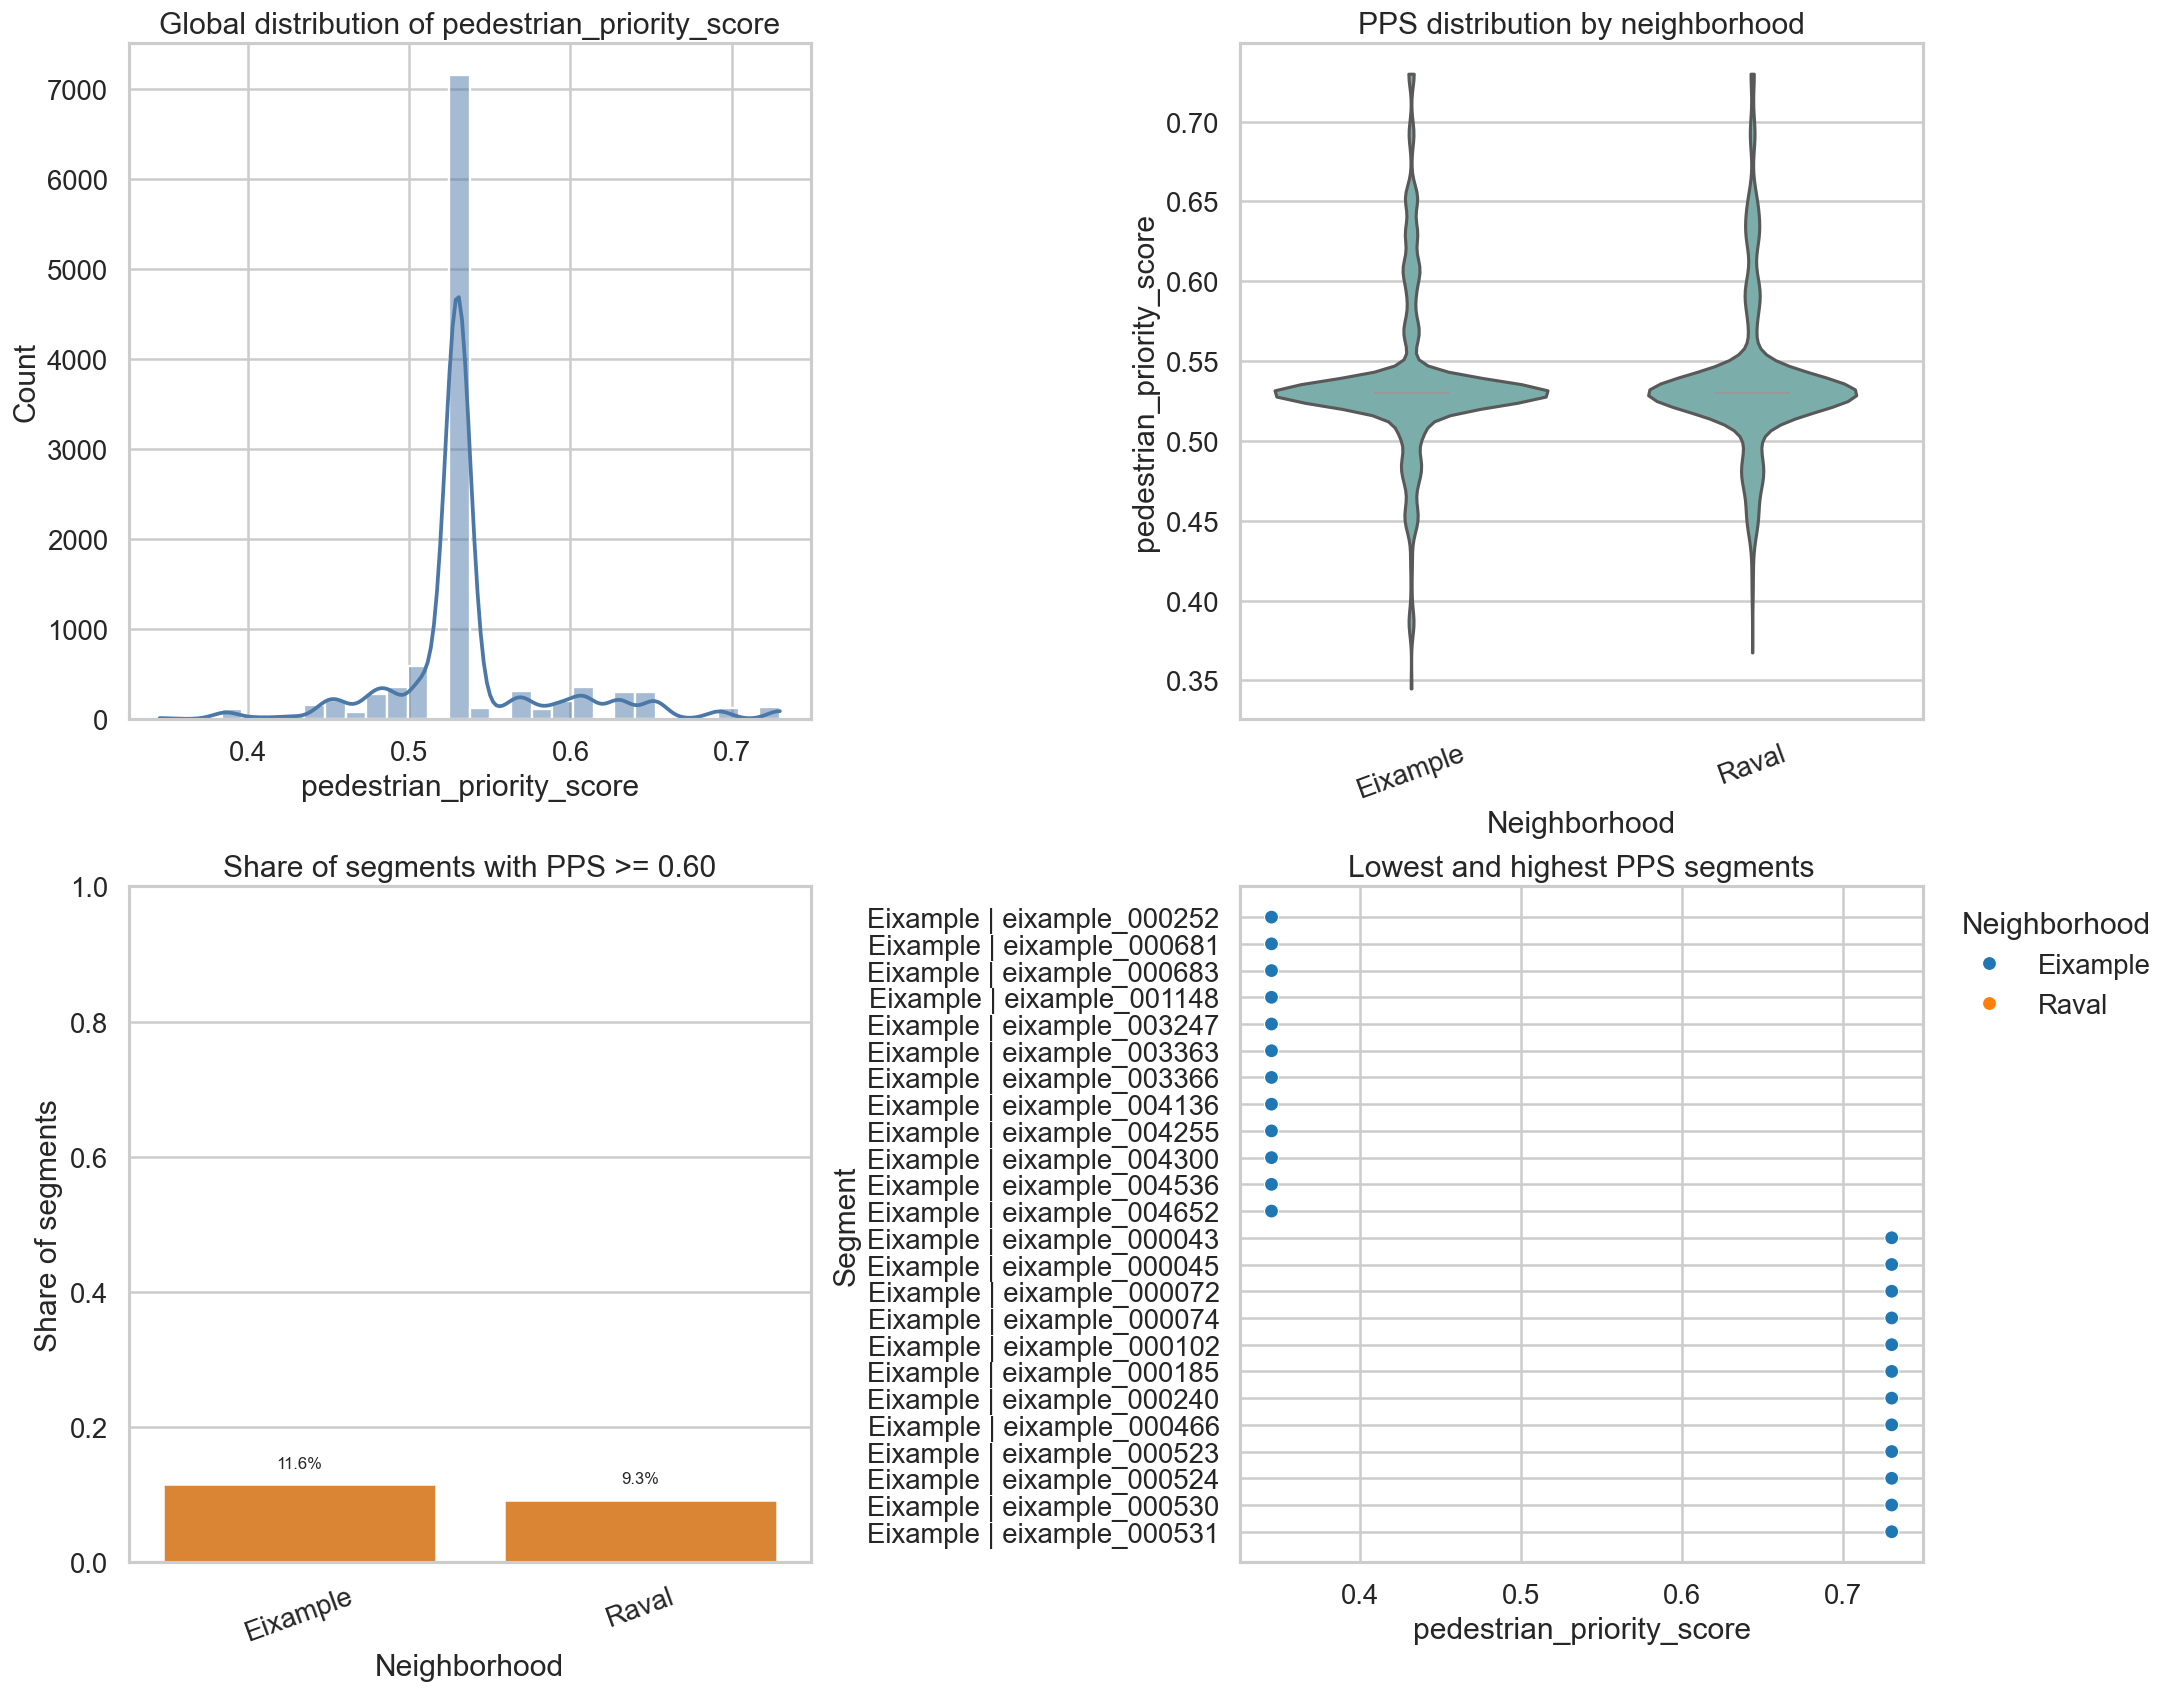

In [26]:
# ── PPS inspection plots ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy() if 'df' in globals() else pd.read_csv(OUTPUT_CSV)
if 'borough' not in plot_df.columns:
    raise ValueError('Expected a borough column in the PPS CSV for plotting.')

neighborhood_labels = {
    'Eixample': 'Eixample',
    'Poble Sec': 'Poble Sec',
    'Raval': 'Raval',
}

plot_df['neighborhood_short'] = plot_df['borough'].map(neighborhood_labels).fillna(plot_df['borough'])
neighborhood_order = (
    plot_df.groupby('neighborhood_short')['pedestrian_priority_score']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

print(f'Loaded {len(plot_df):,} PPS rows from {OUTPUT_CSV.name}')
display(plot_df[['pedestrian_priority_score']].describe().T[['count', 'mean', 'min', 'max']])

threshold = 0.60
high_share = (
    plot_df.assign(is_high=plot_df['pedestrian_priority_score'] >= threshold)
    .groupby('neighborhood_short')['is_high']
    .mean()
    .reindex(neighborhood_order)
)

extremes = pd.concat([
    plot_df.nsmallest(12, 'pedestrian_priority_score'),
    plot_df.nlargest(12, 'pedestrian_priority_score'),
], ignore_index=True)
extremes = extremes.sort_values('pedestrian_priority_score').copy()
extremes['segment_label'] = (
    extremes['neighborhood_short'].astype(str)
    + ' | '
    + extremes['location_id'].astype(str)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
axes = axes.flatten()

sns.histplot(plot_df['pedestrian_priority_score'], bins=30, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Global distribution of pedestrian_priority_score')
axes[0].set_xlabel('pedestrian_priority_score')
axes[0].set_ylabel('Count')

sns.violinplot(
    data=plot_df,
    x='neighborhood_short',
    y='pedestrian_priority_score',
    order=neighborhood_order,
    ax=axes[1],
    inner=None,
    cut=0,
    color='#72B7B2',
)
sns.boxplot(
    data=plot_df,
    x='neighborhood_short',
    y='pedestrian_priority_score',
    order=neighborhood_order,
    ax=axes[1],
    width=0.22,
    showfliers=False,
    color='white',
)
axes[1].set_title('PPS distribution by neighborhood')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('pedestrian_priority_score')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(x=high_share.index, y=high_share.values, ax=axes[2], color='#F58518')
axes[2].set_title(f'Share of segments with PPS >= {threshold:.2f}')
axes[2].set_xlabel('Neighborhood')
axes[2].set_ylabel('Share of segments')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)
for i, value in enumerate(high_share.values):
    axes[2].text(i, value + 0.02, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

sns.scatterplot(
    data=extremes,
    x='pedestrian_priority_score',
    y='segment_label',
    hue='neighborhood_short',
    hue_order=neighborhood_order,
    palette='tab10',
    s=70,
    ax=axes[3],
)
axes[3].set_title('Lowest and highest PPS segments')
axes[3].set_xlabel('pedestrian_priority_score')
axes[3].set_ylabel('Segment')
axes[3].legend(title='Neighborhood', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

plots_dir = REPO_ROOT / 'notebooks' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(plots_dir / 'pps_inspection_plots.png', bbox_inches='tight')

plt.show()